In [1]:
import numpy as np
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt

rootpath = "C:/Users/17934/Desktop/MachineLearning/Program/TrainingFigure"
trans = transforms.ToTensor() # 图像转换器

def get_dataloader_workers(): # 读取图片的子进程数量
    return 4

def load_data_fashion_mnist(batch_size, resize=None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(root=rootpath, train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root=rootpath, train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=get_dataloader_workers()), data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=get_dataloader_workers()))

train_iter, test_iter = load_data_fashion_mnist(256)

def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    result = []
    for i in labels:
        num = int(i) # 把张量格式的数字转换成整数
        name = text_labels[num]
        result.append(name) # 数组元素追加
    return result

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制列表"""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy())
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

In [2]:
"搭建卷积神经网络框架"

net = nn.Sequential(
    nn.Conv2d(1,6,kernel_size=5,padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Conv2d(6,16,kernel_size=5,padding=2),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2,stride=2),
    nn.Flatten(),
    nn.Linear(16*7*7,120),
    nn.ReLU(),
    nn.Linear(120,84),
    nn.ReLU(),
    nn.Linear(84,10),
)

In [3]:
import torch.optim as optim
from torch.utils.data import DataLoader
import time
from typing import Optional, Tuple, List

def get_default_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    return torch.device("cpu")

class Accumulator:
    "累计训练过程中的总损失、正确样本数、总样本数等指标"

    def __init__(self, num_metrics: int):
        self._data: List[float] = [0.0] * num_metrics

    def add(self, *values: float) -> None:
        # 批量添加一组累加值
        if len(values) != len(self._data):
            raise ValueError(f"index number do not match")
        for i in range(len(self._data)):
            self._data[i] += values[i]

    def reset(self) -> None:
        # 清空累加值
        self._data = [0.0] * len(self._data)

    def __getitem__(self, idx: int) -> float:
        # 索引取值
        return self._data[idx]

def calc_batch_correct(logits: torch.Tensor, labels: torch.Tensor) -> int:
    # 计算单批次预测正确的样本数
    # 取概率最大的类别作为预测结果
    preds = torch.argmax(logits, dim=1)
    # 比较预测与真实标签，求和得到正确数
    correct = torch.sum(preds == labels).item()
    return correct

class MetricPlotter:
    "训练指标记录与可视化"
    
    def __init__(self, xlabel: str = "epoch", 
                 legend: List[str] = None,
                 xlim: Tuple[float, float] = None):
        self.xlabel = xlabel
        self.legend = legend if legend else []
        self.xlim = xlim
        self.x_axis: List[float] = []
        self.y_series: List[List[float]] = [[] for _ in self.legend]

    def add(self, x: float, *y_vals: Optional[float]) -> None:
        # 添加一个数据点，None表示该指标本次不更新
        self.x_axis.append(x)
        for i, val in enumerate(y_vals):
            if i < len(self.y_series) and val is not None:
                self.y_series[i].append(val)

    def show(self, figsize: Tuple[int, int] = (10, 6)) -> None:
        # 绘制完整训练曲线
        plt.figure(figsize=figsize)
        for i, label in enumerate(self.legend):
            if len(self.y_series[i]) > 0:
                x_points = self.x_axis[:len(self.y_series[i])]
                plt.plot(x_points, self.y_series[i], label=label, linewidth=1.5)
        plt.xlabel(self.xlabel, fontsize=12)
        plt.ylabel("Metric Value", fontsize=12)
        if self.xlim:
            plt.xlim(self.xlim)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.title("Training Process Metrics", fontsize=14)
        plt.show()

def evaluate_accuracy_gpu(
    model: nn.Module,
    dataloader: DataLoader,
    device: Optional[torch.device] = None
) -> float:
    """
    在GPU上计算模型在数据集上的分类准确率
    Args:
        model: 待评估的PyTorch模型
        dataloader: 数据集加载器
        device: 计算设备
    Returns:
        全局分类准确率，范围 [0, 1]
    """
    # 切换模型为评估模式：关闭Dropout、BatchNorm的训练逻辑
    if isinstance(model, nn.Module):
        model.eval()
        if device is None:
            device = next(model.parameters()).device
    
    # 初始化累加器：统计[正确预测数, 总样本数]
    metric = Accumulator(2)

    # 关闭梯度计算
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            if isinstance(batch_x, list):
                batch_x = [x.to(device, non_blocking=True) for x in batch_x]
            else:
                batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            logits = model(batch_x)

            correct = calc_batch_correct(logits, batch_y)
            total = batch_y.numel()
            metric.add(correct, total)
    
        total_samples = metric[1]
        if total_samples == 0:
            return 0.0
        return metric[0] / total_samples

In [6]:
def train_ch6(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    num_epochs: int,
    lr: float,
    device: torch.device
) -> None:
    """
    CNN模型GPU训练主循环
    Args:
        model: 待训练的神经网络模型
        train_loader: 训练集加载器
        test_loader: 测试集加载器
        num_epochs: 训练总轮数
        lr: SGD优化器学习率
        device: 训练设备
    """
    # ===================== 1. 模型迁移到目标设备 =====================
    model = model.to(device)

    # ===================== 2. 权重初始化 =====================
    def init_weights(m: nn.Module):
        # 逐层初始化回调：对全连接层、卷积层使用Xavier均匀初始化
        if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
            nn.init.xavier_uniform_(m.weight)

    # 递归应用初始化到模型所有子层
    model.apply(init_weights)

    # ===================== 3. 定义优化器与损失函数 =====================
    # 小批量随机梯度下降优化器
    optimizer = optim.SGD(model.parameters(), lr=lr)
    # 交叉熵损失：内置Softmax，多分类任务标准损失
    loss_fn = nn.CrossEntropyLoss()

    # ===================== 4. 初始化训练辅助工具 =====================
    plotter = MetricPlotter(
        xlabel="epoch",
        legend=["train loss", "train acc", "test acc"],
        xlim=(1, num_epochs)
    )
    num_batches = len(train_loader)  # 训练集总批次数

    # ===================== 5. 训练主循环 =====================
    for epoch in range(num_epochs):
        # 切换模型为训练模式
        model.train()
        # 训练指标累加器：[总损失, 正确样本数, 总样本数]
        train_metric = Accumulator(3)

        # 遍历训练集每个批次
        for batch_idx, (batch_x, batch_y) in enumerate(train_loader):

            # 梯度清零
            optimizer.zero_grad()

            # 数据迁移到GPU
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)

            # 前向传播：计算预测值
            logits = model(batch_x)
            # 计算当前批次平均损失
            loss = loss_fn(logits, batch_y)

            # 反向传播：计算损失对所有参数的梯度
            loss.backward()

            # 优化器更新网络参数
            optimizer.step()

            # 统计训练指标
            with torch.no_grad():
                # loss是批次平均值，乘以批次大小得到总损失，方便全局求平均
                total_batch_loss = loss.item() * batch_x.size(0)
                batch_correct = calc_batch_correct(logits, batch_y)
                batch_size = batch_x.size(0)
                train_metric.add(total_batch_loss, batch_correct, batch_size)

        # 更新指标   
        # 计算当前平均训练损失、训练准确率
        avg_train_loss = train_metric[0] / train_metric[2]
        avg_train_acc = train_metric[1] / train_metric[2]

        model.eval()
        with torch.no_grad():
            # 评估测试集准确率
            test_acc = evaluate_accuracy_gpu(model, test_loader, device)
                
        # 记录测试指标
        plotter.add(epoch + 1, None, None, test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Train Acc: {avg_train_acc:.4f} | "
              f"Test Acc: {test_acc:.4f}")

    # ===================== 6. 训练结束，绘制完整曲线 =====================
    plotter.show()

训练设备: cuda
Epoch [1/100] | Train Loss: 1.0815 | Train Acc: 0.5855 | Test Acc: 0.6985
Epoch [2/100] | Train Loss: 0.5210 | Train Acc: 0.8038 | Test Acc: 0.8109
Epoch [3/100] | Train Loss: 0.4193 | Train Acc: 0.8448 | Test Acc: 0.8054
Epoch [4/100] | Train Loss: 0.3744 | Train Acc: 0.8627 | Test Acc: 0.8548
Epoch [5/100] | Train Loss: 0.3468 | Train Acc: 0.8700 | Test Acc: 0.8531
Epoch [6/100] | Train Loss: 0.3284 | Train Acc: 0.8785 | Test Acc: 0.8599
Epoch [7/100] | Train Loss: 0.3104 | Train Acc: 0.8844 | Test Acc: 0.8659
Epoch [8/100] | Train Loss: 0.3002 | Train Acc: 0.8888 | Test Acc: 0.8733
Epoch [9/100] | Train Loss: 0.2868 | Train Acc: 0.8935 | Test Acc: 0.8734
Epoch [10/100] | Train Loss: 0.2776 | Train Acc: 0.8969 | Test Acc: 0.8677
Epoch [11/100] | Train Loss: 0.2663 | Train Acc: 0.9010 | Test Acc: 0.8821
Epoch [12/100] | Train Loss: 0.2595 | Train Acc: 0.9030 | Test Acc: 0.8818
Epoch [13/100] | Train Loss: 0.2531 | Train Acc: 0.9062 | Test Acc: 0.8888
Epoch [14/100] | Train 

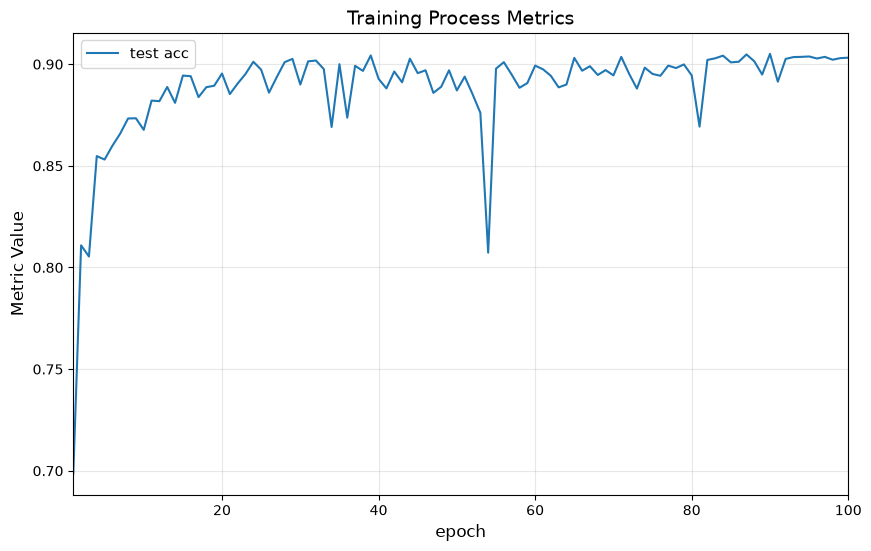

In [7]:
lr = 0.1
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"训练设备: {device}")
train_ch6(net, train_iter, test_iter, num_epochs, lr, device=device)